In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 设置全局样式
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 8)
rcParams['figure.dpi'] = 100

# 定义6个基准测试函数
class BenchmarkFunctions:
    def __init__(self, D=10):
        self.D = D
        
    def sphere(self, x):
        """Sphere函数"""
        return np.sum(x**2)
    
    def rosenbrock(self, x):
        """Rosenbrock函数"""
        return np.sum(100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2)
    
    def ackley(self, x):
        """Ackley函数"""
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(2 * np.pi * x))
        return -20 * np.exp(-0.2 * np.sqrt(sum_sq / self.D)) - \
               np.exp(sum_cos / self.D) + 20 + np.e
    
    def griewank(self, x):
        """Griewank函数"""
        sum_sq = np.sum(x**2)
        prod_cos = np.prod(np.cos(x / np.sqrt(np.arange(1, self.D+1))))
        return sum_sq / 4000 - prod_cos + 1
    
    def rastrigin(self, x):
        """Rastrigin函数"""
        return 10 * self.D + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))
    
    def schwefel(self, x):
        """Schwefel函数"""
        return 418.9829 * self.D - np.sum(x * np.sin(np.sqrt(np.abs(x))))
    
    def get_function(self, name):
        """获取函数对象"""
        functions = {
            'Sphere': self.sphere,
            'Rosenbrock': self.rosenbrock,
            'Ackley': self.ackley,
            'Griewank': self.griewank,
            'Rastrigin': self.rastrigin,
            'Schwefel': self.schwefel
        }
        return functions.get(name, self.sphere)
    
    def get_bounds(self, name):
        """获取函数搜索范围"""
        bounds = {
            'Sphere': (-100, 100),
            'Rosenbrock': (-30, 30),
            'Ackley': (-32, 32),
            'Griewank': (-600, 600),
            'Rastrigin': (-5.12, 5.12),
            'Schwefel': (-500, 500)
        }
        return bounds.get(name, (-100, 100))

In [2]:
class GeneticAlgorithm:
    def __init__(self, D=10, pop_size=50, max_fes=100000):
        self.D = D
        self.pop_size = pop_size
        self.max_fes = max_fes
        self.function = None
        self.bounds = None
        self.best_fitness_history = []
        
    def initialize_population(self):
        """初始化种群"""
        lower, upper = self.bounds
        self.population = np.random.uniform(lower, upper, (self.pop_size, self.D))
        self.fitness = np.array([self.function(ind) for ind in self.population])
        self.fes_count = self.pop_size
        
        # 记录初始最佳
        best_idx = np.argmin(self.fitness)
        self.best_solution = self.population[best_idx].copy()
        self.best_fitness = self.fitness[best_idx]
        self.best_fitness_history.append(self.best_fitness)
        
    def tournament_selection(self, k=2):
        """锦标赛选择"""
        selected = []
        for _ in range(self.pop_size):
            # 随机选择k个个体
            idx = np.random.choice(self.pop_size, k, replace=False)
            # 选择适应度最好的
            best_idx = idx[np.argmin(self.fitness[idx])]
            selected.append(self.population[best_idx])
        return np.array(selected)
    
    def sbx_crossover(self, parents, eta_c=20, pc=0.8):
        """模拟二进制交叉"""
        children = []
        for i in range(0, len(parents), 2):
            if i+1 < len(parents) and np.random.rand() < pc:
                p1, p2 = parents[i], parents[i+1]
                child1, child2 = p1.copy(), p2.copy()
                
                for j in range(self.D):
                    if np.random.rand() <= 0.5:
                        if abs(p1[j] - p2[j]) > 1e-10:
                            if p1[j] < p2[j]:
                                y1, y2 = p1[j], p2[j]
                            else:
                                y1, y2 = p2[j], p1[j]
                            
                            lower, upper = self.bounds
                            y_low, y_up = lower, upper
                            
                            rand = np.random.rand()
                            beta = 1.0 + (2.0 * (y1 - y_low) / (y2 - y1))
                            alpha = 2.0 - beta**(-(eta_c + 1))
                            
                            if rand <= (1.0 / alpha):
                                beta_q = (rand * alpha)**(1.0 / (eta_c + 1))
                            else:
                                beta_q = (1.0 / (2.0 - rand * alpha))**(1.0 / (eta_c + 1))
                            
                            c1 = 0.5 * ((y1 + y2) - beta_q * (y2 - y1))
                            c2 = 0.5 * ((y1 + y2) + beta_q * (y2 - y1))
                            
                            child1[j] = min(max(c1, y_low), y_up)
                            child2[j] = min(max(c2, y_low), y_up)
                children.extend([child1, child2])
            else:
                children.extend([parents[i], parents[i+1]])
        return np.array(children)
    
    def polynomial_mutation(self, children, eta_m=20, pm=0.1):
        """多项式变异"""
        lower, upper = self.bounds
        for i in range(len(children)):
            for j in range(self.D):
                if np.random.rand() < pm:
                    y = children[i, j]
                    y_low, y_up = lower, upper
                    
                    delta1 = (y - y_low) / (y_up - y_low)
                    delta2 = (y_up - y) / (y_up - y_low)
                    
                    rand = np.random.rand()
                    mut_pow = 1.0 / (eta_m + 1.0)
                    
                    if rand < 0.5:
                        xy = 1.0 - delta1
                        val = 2.0 * rand + (1.0 - 2.0 * rand) * (xy**(eta_m + 1.0))
                        delta_q = val**mut_pow - 1.0
                    else:
                        xy = 1.0 - delta2
                        val = 2.0 * (1.0 - rand) + 2.0 * (rand - 0.5) * (xy**(eta_m + 1.0))
                        delta_q = 1.0 - val**mut_pow
                    
                    y = y + delta_q * (y_up - y_low)
                    children[i, j] = min(max(y, y_low), y_up)
        return children
    
    def optimize(self, func_name, benchmark):
        """执行优化"""
        self.function = benchmark.get_function(func_name)
        self.bounds = benchmark.get_bounds(func_name)
        
        self.initialize_population()
        
        # 记录间隔（用于绘图）
        record_interval = max(1, self.max_fes // 1000)
        
        while self.fes_count < self.max_fes:
            # 选择
            parents = self.tournament_selection(k=2)
            
            # 交叉
            children = self.sbx_crossover(parents, pc=0.8)
            
            # 变异
            children = self.polynomial_mutation(children, pm=1.0/self.D)
            
            # 计算子代适应度
            child_fitness = np.array([self.function(ind) for ind in children])
            self.fes_count += len(children)
            
            # 更新种群
            self.population = children
            self.fitness = child_fitness
            
            # 更新最佳解
            current_best_idx = np.argmin(child_fitness)
            current_best_fitness = child_fitness[current_best_idx]
            
            if current_best_fitness < self.best_fitness:
                self.best_solution = children[current_best_idx].copy()
                self.best_fitness = current_best_fitness
            
            # 记录收敛历史
            if self.fes_count % record_interval == 0:
                self.best_fitness_history.append(self.best_fitness)
                
            if self.fes_count >= self.max_fes:
                break
        
        return self.best_solution, self.best_fitness, self.best_fitness_history

In [3]:
class ParticleSwarmOptimization:
    def __init__(self, D=10, pop_size=50, max_fes=100000):
        self.D = D
        self.pop_size = pop_size
        self.max_fes = max_fes
        self.function = None
        self.bounds = None
        self.best_fitness_history = []
        
    def initialize_swarm(self):
        """初始化粒子群"""
        lower, upper = self.bounds
        
        # 初始化位置
        self.positions = np.random.uniform(lower, upper, (self.pop_size, self.D))
        
        # 初始化速度（限制在搜索范围的20%内）
        v_max = 0.2 * (upper - lower)
        self.velocities = np.random.uniform(-v_max, v_max, (self.pop_size, self.D))
        
        # 计算初始适应度
        self.fitness = np.array([self.function(pos) for pos in self.positions])
        self.fes_count = self.pop_size
        
        # 个体最优
        self.pbest_positions = self.positions.copy()
        self.pbest_fitness = self.fitness.copy()
        
        # 全局最优
        self.gbest_idx = np.argmin(self.fitness)
        self.gbest_position = self.positions[self.gbest_idx].copy()
        self.gbest_fitness = self.fitness[self.gbest_idx]
        
        self.best_fitness_history.append(self.gbest_fitness)
        
    def update_velocity_position(self, w_max=0.9, w_min=0.4, c1=2.0, c2=2.0):
        """更新速度和位置"""
        lower, upper = self.bounds
        v_max = 0.2 * (upper - lower)
        
        # 线性递减惯性权重
        current_iter = self.fes_count // self.pop_size
        total_iter = self.max_fes // self.pop_size
        w = w_max - (w_max - w_min) * current_iter / total_iter
        
        for i in range(self.pop_size):
            r1, r2 = np.random.rand(self.D), np.random.rand(self.D)
            
            # 更新速度
            cognitive = c1 * r1 * (self.pbest_positions[i] - self.positions[i])
            social = c2 * r2 * (self.gbest_position - self.positions[i])
            self.velocities[i] = w * self.velocities[i] + cognitive + social
            
            # 速度限制
            self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)
            
            # 更新位置
            self.positions[i] += self.velocities[i]
            self.positions[i] = np.clip(self.positions[i], lower, upper)
    
    def optimize(self, func_name, benchmark):
        """执行优化"""
        self.function = benchmark.get_function(func_name)
        self.bounds = benchmark.get_bounds(func_name)
        
        self.initialize_swarm()
        
        # 记录间隔
        record_interval = max(1, self.max_fes // 1000)
        
        while self.fes_count < self.max_fes:
            # 更新速度和位置
            self.update_velocity_position()
            
            # 计算适应度
            new_fitness = np.array([self.function(pos) for pos in self.positions])
            self.fes_count += self.pop_size
            
            # 更新个体最优
            improved_idx = new_fitness < self.pbest_fitness
            self.pbest_fitness[improved_idx] = new_fitness[improved_idx]
            self.pbest_positions[improved_idx] = self.positions[improved_idx]
            
            # 更新全局最优
            current_best_idx = np.argmin(new_fitness)
            if new_fitness[current_best_idx] < self.gbest_fitness:
                self.gbest_fitness = new_fitness[current_best_idx]
                self.gbest_position = self.positions[current_best_idx].copy()
            
            # 更新适应度
            self.fitness = new_fitness
            
            # 记录收敛历史
            if self.fes_count % record_interval == 0:
                self.best_fitness_history.append(self.gbest_fitness)
                
            if self.fes_count >= self.max_fes:
                break
        
        return self.gbest_position, self.gbest_fitness, self.best_fitness_history

In [8]:
def run_experiment(func_names, n_runs=25, D=10, max_fes=100000, pop_size=50):
    """运行实验，收集结果"""
    benchmark = BenchmarkFunctions(D)
    
    results = {
        'GA': {'final_fitness': {}, 'convergence': {}, 'all_runs': {}},
        'PSO': {'final_fitness': {}, 'convergence': {}, 'all_runs': {}}
    }
    
    for func_name in func_names:
        print(f"正在测试函数: {func_name}")
        
        # GA结果
        ga_final_fitness = []
        ga_all_convergence = []
        
        # PSO结果
        pso_final_fitness = []
        pso_all_convergence = []
        
        for run in range(n_runs):
            print(f"  运行 {run+1}/{n_runs}", end='\r')
            
            # GA
            ga = GeneticAlgorithm(D, pop_size, max_fes)
            _, best_fitness, convergence = ga.optimize(func_name, benchmark)
            ga_final_fitness.append(best_fitness)
            ga_all_convergence.append(convergence)
            
            # PSO
            pso = ParticleSwarmOptimization(D, pop_size, max_fes)
            _, best_fitness, convergence = pso.optimize(func_name, benchmark)
            pso_final_fitness.append(best_fitness)
            pso_all_convergence.append(convergence)
        
        print(f"  函数 {func_name} 测试完成!")
        
        # 存储结果
        results['GA']['final_fitness'][func_name] = ga_final_fitness
        results['PSO']['final_fitness'][func_name] = pso_final_fitness
        results['GA']['all_runs'][func_name] = ga_all_convergence
        results['PSO']['all_runs'][func_name] = pso_all_convergence
        
        # 计算平均收敛曲线
        min_len = min([len(c) for c in ga_all_convergence])
        ga_avg_convergence = np.mean([c[:min_len] for c in ga_all_convergence], axis=0)
        results['GA']['convergence'][func_name] = ga_avg_convergence
        
        min_len = min([len(c) for c in pso_all_convergence])
        pso_avg_convergence = np.mean([c[:min_len] for c in pso_all_convergence], axis=0)
        results['PSO']['convergence'][func_name] = pso_avg_convergence
    
    return results

def plot_convergence_curves(results, func_names):
    """绘制收敛曲线对比图"""
    n_funcs = len(func_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, func_name in enumerate(func_names):
        ax = axes[idx]
        
        # 获取收敛数据
        ga_convergence = results['GA']['convergence'][func_name]
        pso_convergence = results['PSO']['convergence'][func_name]
        
        # 生成X轴（函数评价次数）
        x_ga = np.linspace(50, 100000, len(ga_convergence))
        x_pso = np.linspace(50, 100000, len(pso_convergence))
        
        # 绘制曲线
        ax.semilogy(x_ga, ga_convergence, 'b-', linewidth=2, label='GA')
        ax.semilogy(x_pso, pso_convergence, 'r--', linewidth=2, label='PSO')
        
        # 设置坐标轴
        ax.set_xlabel('Function Evaluations', fontsize=10)
        ax.set_ylabel('Average Best Fitness (log)', fontsize=10)
        ax.set_title(f'{func_name} fuction', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # 添加最终值标注
        final_ga = results['GA']['final_fitness'][func_name]
        final_pso = results['PSO']['final_fitness'][func_name]
        ax.text(0.05, 0.95, f'GA: {np.mean(final_ga):.2e}\nPSO: {np.mean(final_pso):.2e}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Comparative Analysis of Convergence Curves for GA and PSO', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('convergence_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_boxplots(results, func_names):
    """绘制箱线图对比"""
    n_funcs = len(func_names)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, func_name in enumerate(func_names):
        ax = axes[idx]
        
        # 获取最终适应度数据
        ga_data = results['GA']['final_fitness'][func_name]
        pso_data = results['PSO']['final_fitness'][func_name]
        
        # 转换为对数尺度（如果是正数）
        if min(min(ga_data), min(pso_data)) > 0:
            ga_data_log = np.log10(ga_data)
            pso_data_log = np.log10(pso_data)
            data_to_plot = [ga_data_log, pso_data_log]
            ylabel = 'Final Fitness (log10)'
        else:
            data_to_plot = [ga_data, pso_data]
            ylabel = 'Final Fitness'
        
        # 绘制箱线图
        box = ax.boxplot(data_to_plot, patch_artist=True, 
                         labels=['GA', 'PSO'], widths=0.6)
        
        # 设置颜色
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        
        # 添加散点显示所有数据点
        for i, data in enumerate(data_to_plot):
            x = np.random.normal(i+1, 0.04, size=len(data))
            ax.scatter(x, data, alpha=0.6, s=20, color='black')

        ax.set_title(f'{func_name} function', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 添加统计信息
        stats_text = f'GA mean: {np.mean(ga_data):.2e}\nPSO mean: {np.mean(pso_data):.2e}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('GA and PSO Final Solution Distribution Boxplots Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boxplot_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_performance_radar(results, func_names):
    """绘制性能雷达图（综合对比）"""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='polar')
    
    # 计算每个算法在每个函数上的相对性能得分
    # 这里使用排名得分：第一名得1分，第二名得0.5分
    scores_ga = []
    scores_pso = []
    
    for func_name in func_names:
        ga_mean = np.mean(results['GA']['final_fitness'][func_name])
        pso_mean = np.mean(results['PSO']['final_fitness'][func_name])
        
        if ga_mean < pso_mean:  # GA更好
            scores_ga.append(1.0)
            scores_pso.append(0.5)
        elif pso_mean < ga_mean:  # PSO更好
            scores_ga.append(0.5)
            scores_pso.append(1.0)
        else:  # 平局
            scores_ga.append(0.75)
            scores_pso.append(0.75)
    
    # 角度设置
    angles = np.linspace(0, 2*np.pi, len(func_names), endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形
    
    scores_ga += scores_ga[:1]
    scores_pso += scores_pso[:1]
    
    # 绘制雷达图
    ax.plot(angles, scores_ga, 'o-', linewidth=2, label='GA')
    ax.fill(angles, scores_ga, alpha=0.25)
    
    ax.plot(angles, scores_pso, 's-', linewidth=2, label='PSO')
    ax.fill(angles, scores_pso, alpha=0.25)
    
    # 设置角度标签
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(func_names, fontsize=10)
    
    # 设置径向标签
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['Poor', 'Medium', 'Good', 'Excellent'], fontsize=9)
    
    ax.set_title('Algorithm Performance Radar Chart Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('performance_radar.png', dpi=300, bbox_inches='tight')
    plt.show()

开始实验：GA与PSO算法性能对比
维度: 10, 运行次数: 25, 最大FES: 100000
正在测试函数: Sphere
  函数 Sphere 测试完成!
正在测试函数: Rosenbrock
  函数 Rosenbrock 测试完成!
正在测试函数: Ackley
  函数 Ackley 测试完成!
正在测试函数: Griewank
  函数 Griewank 测试完成!
正在测试函数: Rastrigin
  函数 Rastrigin 测试完成!
正在测试函数: Schwefel
  函数 Schwefel 测试完成!

实验完成，开始生成图像...
生成收敛曲线图...


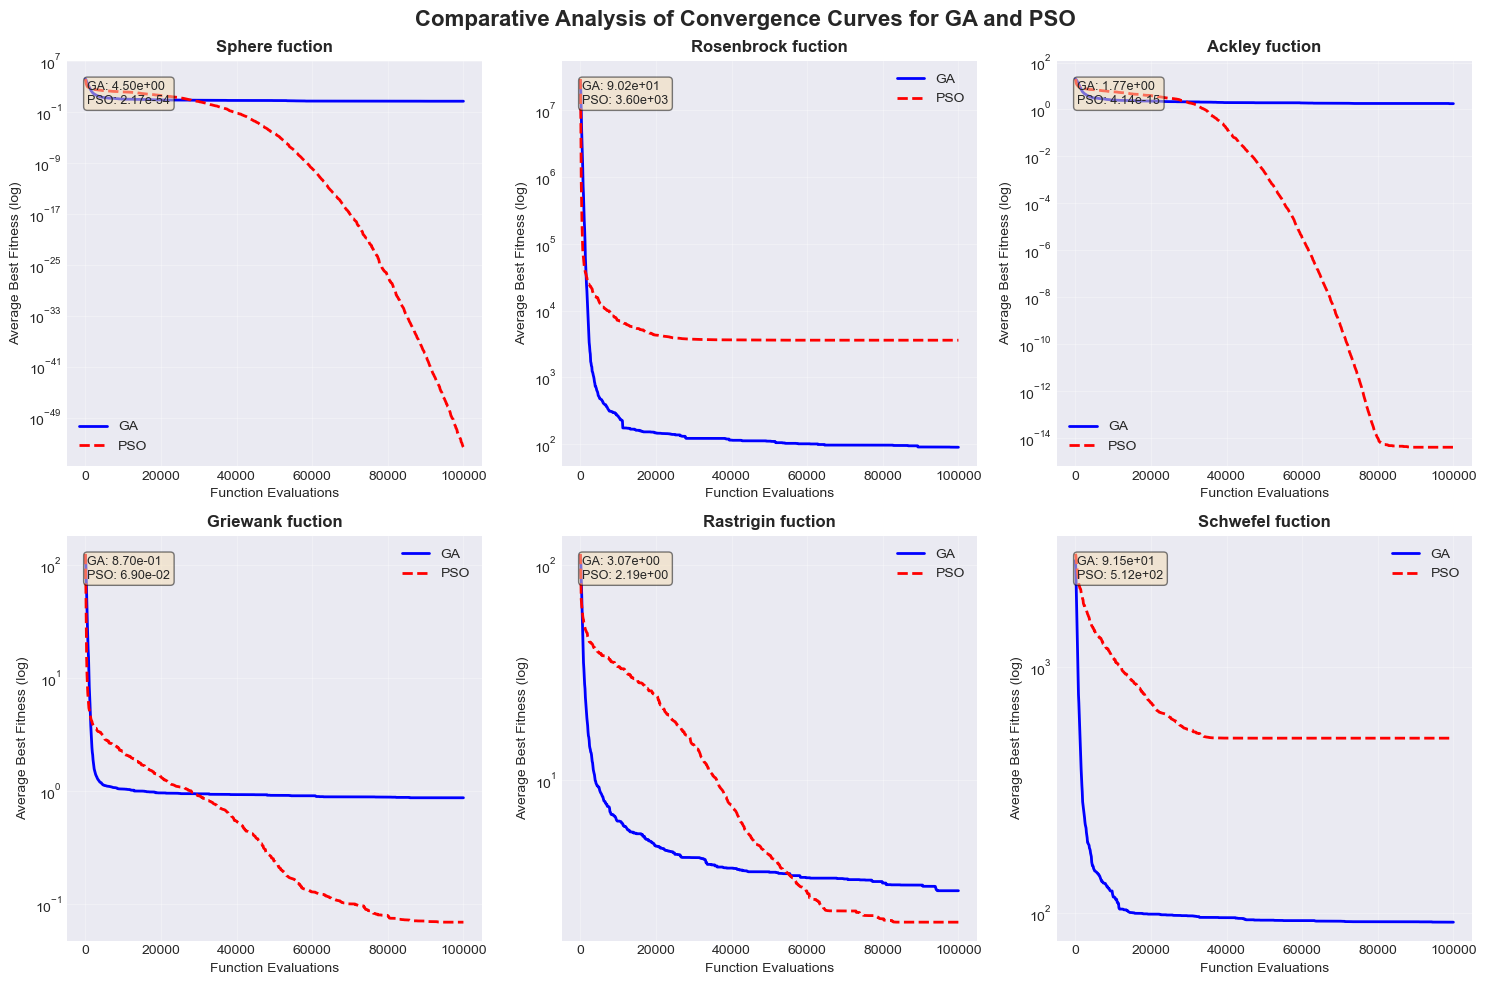

生成箱线图...


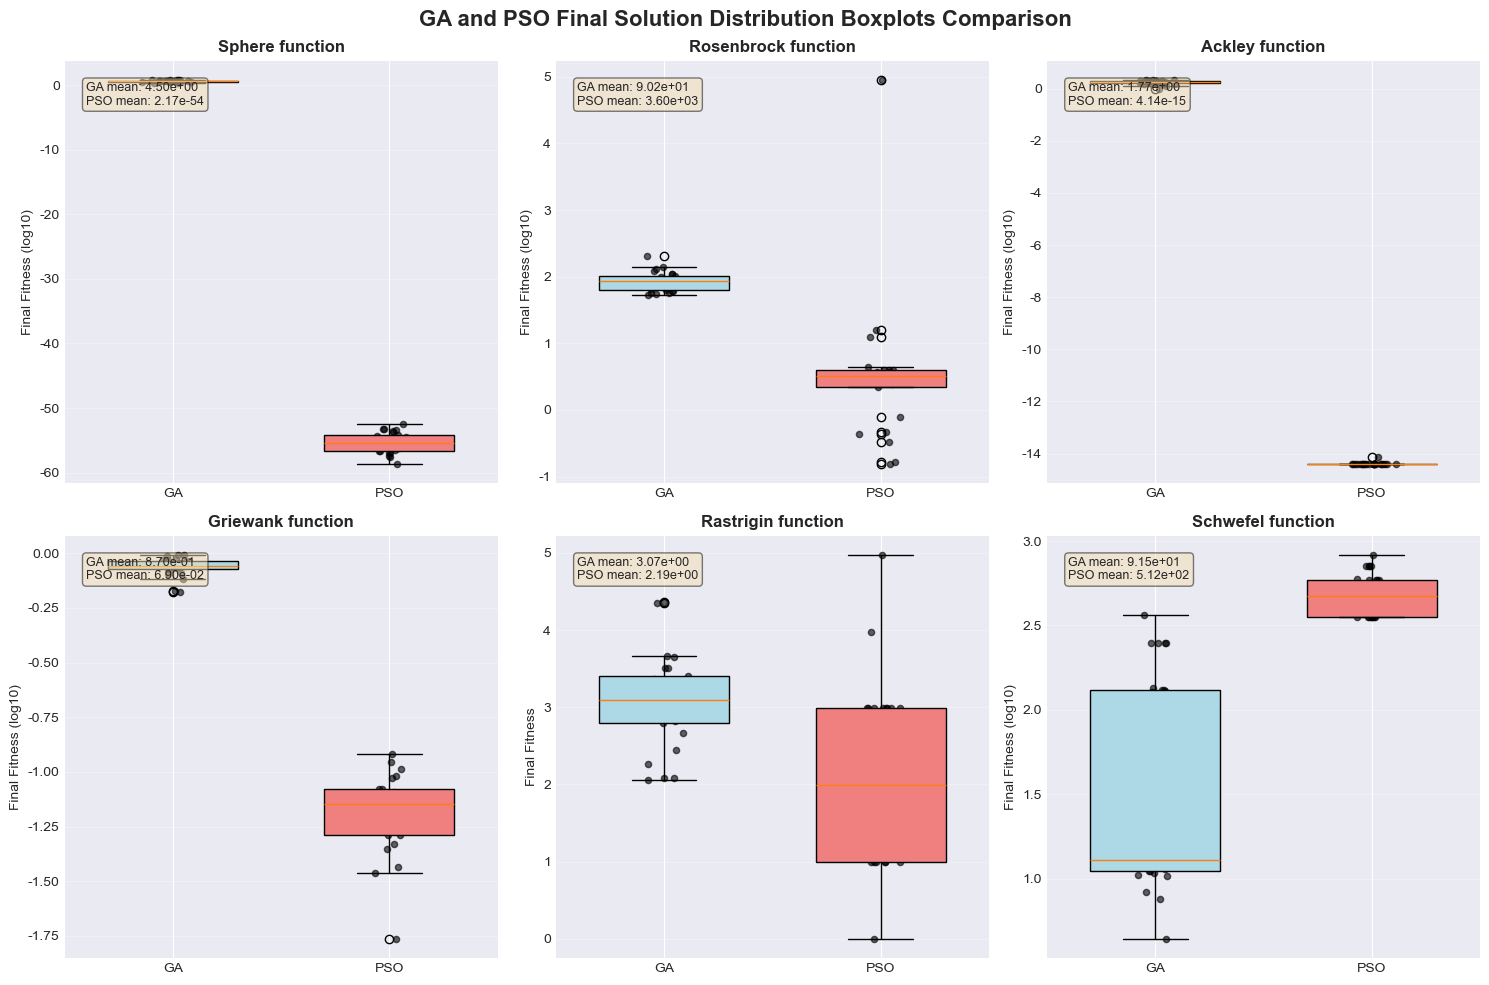

生成性能雷达图...


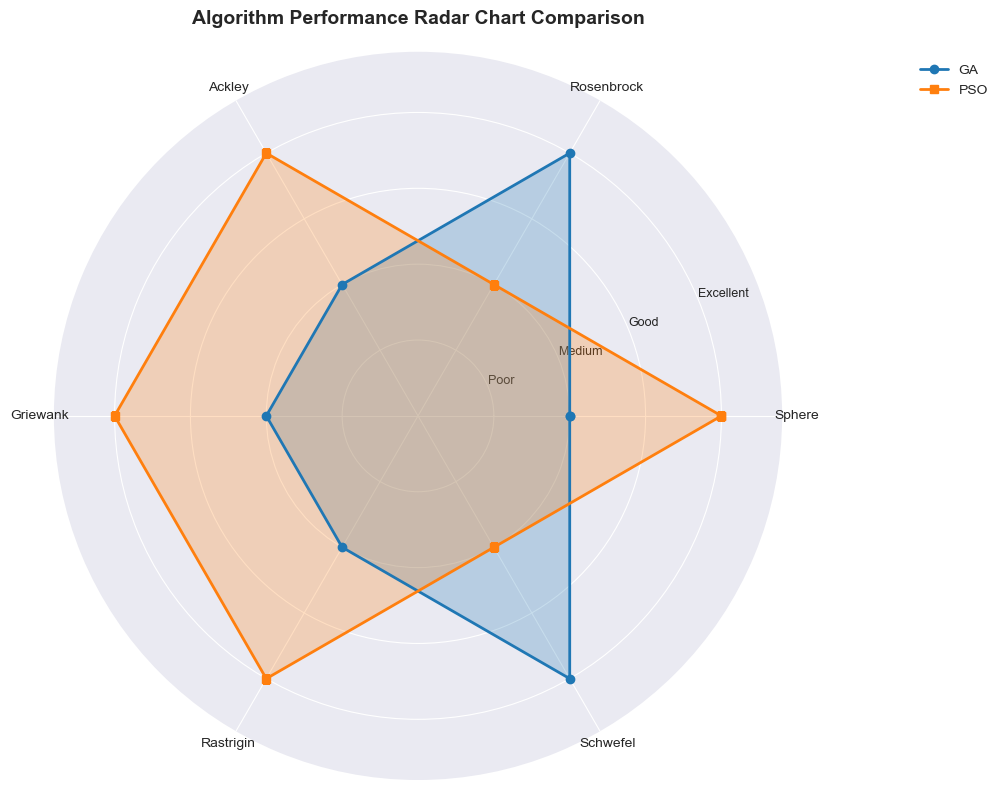


算法性能统计摘要：

Sphere 函数：
  GA:   均值=4.50e+00, 标准差=1.13e+00
  PSO:  均值=2.17e-54, 标准差=6.38e-54
  胜出算法: PSO (优势: 207528430068611508346439292652032789538459494503824752640.0%)

Rosenbrock 函数：
  GA:   均值=9.02e+01, 标准差=3.36e+01
  PSO:  均值=3.60e+03, 标准差=1.76e+04
  胜出算法: GA (优势: 3896.3%)

Ackley 函数：
  GA:   均值=1.77e+00, 标准差=2.89e-01
  PSO:  均值=4.14e-15, 标准差=6.96e-16
  胜出算法: PSO (优势: 42849627197670160.0%)

Griewank 函数：
  GA:   均值=8.70e-01, 标准差=7.99e-02
  PSO:  均值=6.90e-02, 标准差=2.42e-02
  胜出算法: PSO (优势: 1161.6%)

Rastrigin 函数：
  GA:   均值=3.07e+00, 标准差=6.03e-01
  PSO:  均值=2.19e+00, 标准差=1.09e+00
  胜出算法: PSO (优势: 40.0%)

Schwefel 函数：
  GA:   均值=9.15e+01, 标准差=1.05e+02
  PSO:  均值=5.12e+02, 标准差=1.41e+02
  胜出算法: GA (优势: 459.8%)

所有图像已保存为PNG文件：
1. convergence_curves.png - 收敛曲线对比图
2. boxplot_comparison.png - 箱线图对比
3. performance_radar.png - 性能雷达图


In [9]:

"""主程序：运行完整实验并生成图像"""
# 定义6个测试函数
func_names = ['Sphere', 'Rosenbrock', 'Ackley', 'Griewank', 'Rastrigin', 'Schwefel']

# 实验参数
D = 10
n_runs = 25
max_fes = 100000
pop_size = 50

print("=" * 60)
print("开始实验：GA与PSO算法性能对比")
print(f"维度: {D}, 运行次数: {n_runs}, 最大FES: {max_fes}")
print("=" * 60)

# 运行实验（注意：这可能需要一些时间）
results = run_experiment(func_names, n_runs, D, max_fes, pop_size)

print("\n" + "=" * 60)
print("实验完成，开始生成图像...")
print("=" * 60)

# 生成收敛曲线图
print("生成收敛曲线图...")
plot_convergence_curves(results, func_names)

# 生成箱线图
print("生成箱线图...")
plot_boxplots(results, func_names)

# 生成雷达图
print("生成性能雷达图...")
plot_performance_radar(results, func_names)

# 打印统计摘要
print("\n" + "=" * 60)
print("算法性能统计摘要：")
print("=" * 60)

for func_name in func_names:
    print(f"\n{func_name} 函数：")
    ga_mean = np.mean(results['GA']['final_fitness'][func_name])
    ga_std = np.std(results['GA']['final_fitness'][func_name])
    pso_mean = np.mean(results['PSO']['final_fitness'][func_name])
    pso_std = np.std(results['PSO']['final_fitness'][func_name])
    
    print(f"  GA:   均值={ga_mean:.2e}, 标准差={ga_std:.2e}")
    print(f"  PSO:  均值={pso_mean:.2e}, 标准差={pso_std:.2e}")
    
    if ga_mean < pso_mean:
        print(f"  胜出算法: GA (优势: {(pso_mean-ga_mean)/ga_mean*100:.1f}%)")
    else:
        print(f"  胜出算法: PSO (优势: {(ga_mean-pso_mean)/pso_mean*100:.1f}%)")
    
print("\n所有图像已保存为PNG文件：")
print("1. convergence_curves.png - 收敛曲线对比图")
print("2. boxplot_comparison.png - 箱线图对比")
print("3. performance_radar.png - 性能雷达图")



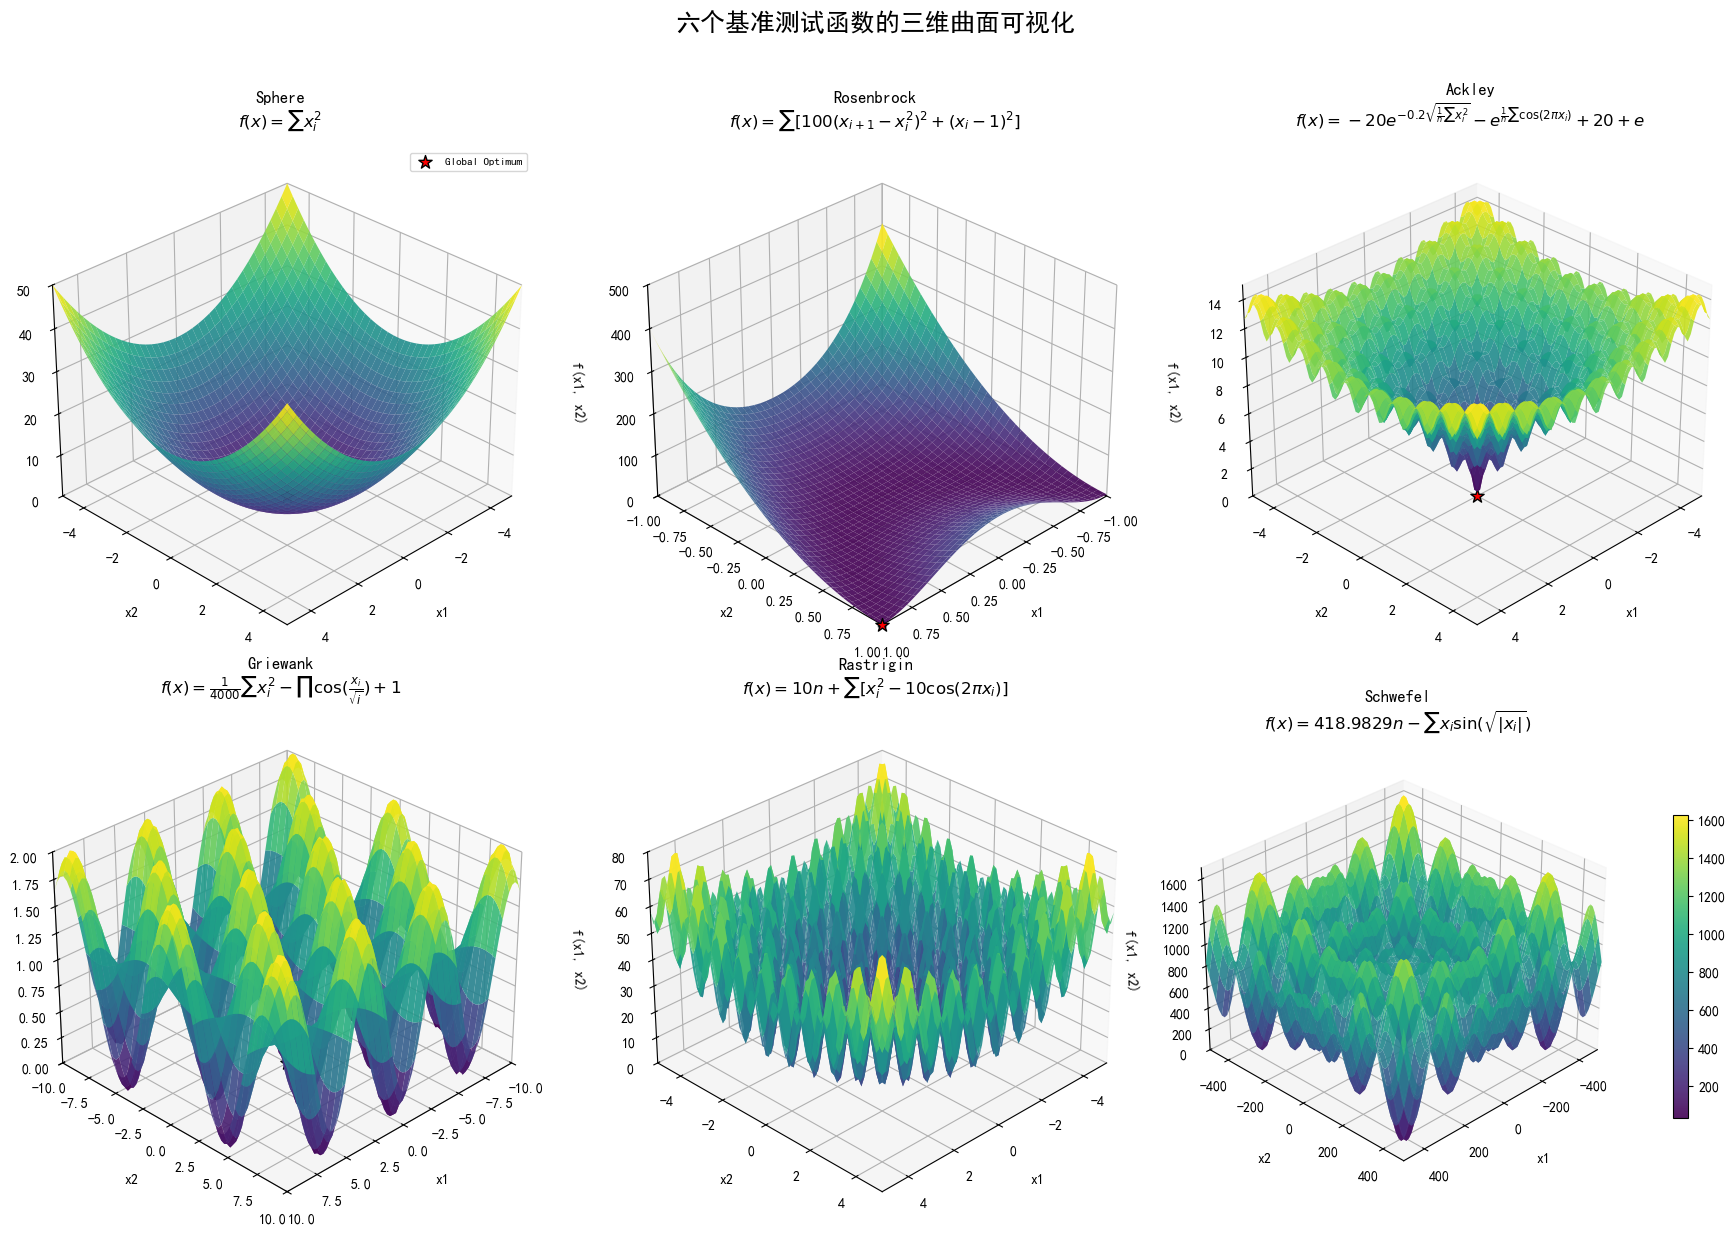

表3-1：六个基准测试函数特性总结
函数名称            搜索范围                 全局最优值           主要特征
--------------------------------------------------------------------------------
Sphere          [-100, 100]^D        0               连续、凸、单峰、可分
Rosenbrock      [-30, 30]^D          0               单峰、非线性、不可分、病态谷底
Ackley          [-32, 32]^D          0               多峰、非凸、连续、不可分
Griewank        [-600, 600]^D        0               多峰、连续、部分可分
Rastrigin       [-5.12, 5.12]^D      0               多峰、可分、高度非线性
Schwefel        [-500, 500]^D        0               多峰、欺骗性强、最优解在边界


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['figure.dpi'] = 100

# 定义六个基准函数
def sphere(x, y):
    return x**2 + y**2

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def ackley(x, y):
    return -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2))) - \
           np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))) + 20 + np.e

def griewank(x, y):
    return (x**2 + y**2) / 4000 - np.cos(x) * np.cos(y / np.sqrt(2)) + 1

def rastrigin(x, y):
    return 20 + (x**2 - 10 * np.cos(2 * np.pi * x)) + \
           (y**2 - 10 * np.cos(2 * np.pi * y))

def schwefel(x, y):
    return 837.9658 - (x * np.sin(np.sqrt(np.abs(x))) + 
                      y * np.sin(np.sqrt(np.abs(y))))

# 创建图形和子图
fig = plt.figure(figsize=(18, 12))
fig.suptitle('六个基准测试函数的三维曲面可视化', fontsize=18, fontweight='bold', y=1.02)

# 定义函数信息
functions = [
    ('Sphere\n$f(x) = \sum x_i^2$', sphere, (-5, 5), (-5, 5), (0, 50)),
    ('Rosenbrock\n$f(x) = \sum[100(x_{i+1}-x_i^2)^2+(x_i-1)^2]$', rosenbrock, (-1, 1), (-1, 1), (0, 500)),
    ('Ackley\n$f(x) = -20e^{-0.2\\sqrt{\\frac{1}{n}\sum x_i^2}} - e^{\\frac{1}{n}\sum\\cos(2\pi x_i)} + 20 + e$', 
     ackley, (-5, 5), (-5, 5), (0, 15)),
    ('Griewank\n$f(x) = \\frac{1}{4000}\sum x_i^2 - \prod\\cos(\\frac{x_i}{\\sqrt{i}}) + 1$', 
     griewank, (-10, 10), (-10, 10), (0, 2)),
    ('Rastrigin\n$f(x) = 10n + \sum[x_i^2 - 10\\cos(2\pi x_i)]$', 
     rastrigin, (-5.12, 5.12), (-5.12, 5.12), (0, 80)),
    ('Schwefel\n$f(x) = 418.9829n - \sum x_i\\sin(\\sqrt{|x_i|})$', 
     schwefel, (-500, 500), (-500, 500), (0, 1700))
]

# 生成每个函数的3D曲面图
for idx, (title, func, x_range, y_range, z_range) in enumerate(functions, 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    
    # 创建网格
    x = np.linspace(x_range[0], x_range[1], 80)
    y = np.linspace(y_range[0], y_range[1], 80)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    # 绘制3D曲面
    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, 
                          alpha=0.9, linewidth=0.5, 
                          antialiased=True, rstride=2, cstride=2)
    
    # 设置视角
    ax.view_init(elev=30, azim=45)
    
    # 设置坐标轴标签
    ax.set_xlabel('x1', fontsize=10, labelpad=10)
    ax.set_ylabel('x2', fontsize=10, labelpad=10)
    ax.set_zlabel('f(x1, x2)', fontsize=10, labelpad=10)
    
    # 设置坐标轴范围
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.set_zlim(z_range)
    
    # 设置标题（包含数学公式）
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # 添加颜色条
    if idx == 6:  # 只在最后一个图上添加颜色条
        fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1)
    
    # 添加网格
    ax.grid(True, alpha=0.3)
    
    # 标记全局最优点（如果在该显示范围内）
    if title.startswith('Sphere') or title.startswith('Rosenbrock') or \
       title.startswith('Ackley') or title.startswith('Griewank') or \
       title.startswith('Rastrigin'):
        # 这些函数的全局最优点在(0,0)或(1,1)
        if 'Rosenbrock' in title:
            ax.scatter([1], [1], [func(1, 1)], color='red', s=100, 
                      marker='*', edgecolors='black', linewidth=1, 
                      label='Global Optimum', zorder=5)
        else:
            ax.scatter([0], [0], [func(0, 0)], color='red', s=100, 
                      marker='*', edgecolors='black', linewidth=1, 
                      label='Global Optimum', zorder=5)
        if idx == 1:  # 只在第一个图上显示图例
            ax.legend(loc='upper right', fontsize=8)

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('benchmark_functions_3d_visualization.png', dpi=300, 
            bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# 打印函数特性表格
print("="*80)
print("表3-1：六个基准测试函数特性总结")
print("="*80)
print(f"{'函数名称':<15} {'搜索范围':<20} {'全局最优值':<15} {'主要特征'}")
print("-"*80)

function_properties = [
    ("Sphere", "[-100, 100]^D", "0", "连续、凸、单峰、可分"),
    ("Rosenbrock", "[-30, 30]^D", "0", "单峰、非线性、不可分、病态谷底"),
    ("Ackley", "[-32, 32]^D", "0", "多峰、非凸、连续、不可分"),
    ("Griewank", "[-600, 600]^D", "0", "多峰、连续、部分可分"),
    ("Rastrigin", "[-5.12, 5.12]^D", "0", "多峰、可分、高度非线性"),
    ("Schwefel", "[-500, 500]^D", "0", "多峰、欺骗性强、最优解在边界")
]

for name, bounds, optimum, features in function_properties:
    print(f"{name:<15} {bounds:<20} {optimum:<15} {features}")

print("="*80)